# Week 4 - Bag of Words dan TF-IDF Review Aplikasi Amazon Shopping

Notebook ini digunakan untuk membuat representasi teks menggunakan Bag of Words dan TF-IDF berdasarkan dataset review aplikasi Amazon Shopping yang telah melalui tahap preprocessing dan sentiment analysis.

## Tujuan Notebook
1. Membaca dataset hasil sentiment analysis.
2. Menggunakan seluruh data review yang tersedia.
3. Menggunakan kolom `final_clean_text` sebagai data teks utama.
4. Membuat representasi teks menggunakan Bag of Words.
5. Membuat representasi teks menggunakan TF-IDF.
6. Menampilkan top words berdasarkan frekuensi Bag of Words.
7. Menampilkan top words berdasarkan skor TF-IDF.
8. Menampilkan analisis unigram dan bigram.
9. Menampilkan visualisasi hasil BoW dan TF-IDF.
10. Menyimpan ringkasan hasil BoW dan TF-IDF ke file CSV.

## Sumber Data
- Aplikasi: Amazon Shopping
- File input: `data/amazon_reviews_sentiment.csv`

In [42]:
# ============================================================
# INSTAL & IMPORT LIBRARY
# ============================================================

!pip install scikit-learn spacy wordcloud openpyxl tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [43]:
# ============================================================
# KONFIGURASI AWAL
# ============================================================

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Dataset hasil sentiment analysis dari GitHub
DATA_URL = "https://media.githubusercontent.com/media/ayualfia/PBA-Amazon-SentimentAnalysis/main/data/amazon_reviews_sentiment.csv"

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

BOW_UNIGRAM_OUTPUT = os.path.join(DATA_DIR, "amazon_bow_unigram_top_words.csv")
BOW_BIGRAM_OUTPUT = os.path.join(DATA_DIR, "amazon_bow_bigram_top_words.csv")
BOW_TRIGRAM_OUTPUT = os.path.join(DATA_DIR, "amazon_bow_trigram_top_words.csv")

TFIDF_UNIGRAM_OUTPUT = os.path.join(DATA_DIR, "amazon_tfidf_unigram_top_words.csv")
TFIDF_BIGRAM_OUTPUT = os.path.join(DATA_DIR, "amazon_tfidf_bigram_top_words.csv")

BOW_MATRIX_SAMPLE_OUTPUT = os.path.join(DATA_DIR, "amazon_bow_matrix_sample.csv")
EXCEL_OUTPUT = os.path.join(DATA_DIR, "amazon_bow_tfidf_summary.xlsx")

print("Input data:")
print(DATA_URL)

print("\nFolder output:")
print(DATA_DIR)

Input data:
https://media.githubusercontent.com/media/ayualfia/PBA-Amazon-SentimentAnalysis/main/data/amazon_reviews_sentiment.csv

Folder output:
data


In [44]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_URL, low_memory=False)

print("Dataset berhasil dimuat.")
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

df.head()

Dataset berhasil dimuat.
Jumlah baris: 332562
Jumlah kolom: 13


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,final_clean_text,final_stemmed_text,polarity,subjectivity,sentiment_textblob,sentiment_rating
0,8013262e-eb1e-4063-a81f-bedec80a5db9,A Google user,"not compatible with Android tablets , Amazon y...",1,0,32.5.0.100,2026-03-09 18:57:26,compatible android tablet lost mind ever made ...,compat android tablet lost mind ever made deci...,-0.112500,0.125000,Negative,Negative
1,ca281212-4ef4-4ffc-bc7b-777a8d76fdd1,A Google user,You cannot complete a return on Android at all...,1,0,32.5.0.100,2026-03-09 18:51:08,cannot complete return android leaf stuck port...,cannot complet return android leaf stuck porti...,0.100000,0.400000,Positive,Negative
2,f5cf5ff1-a4d3-4b17-834e-f2d9a6574929,A Google user,app keeps crashing,2,0,32.5.0.100,2026-03-09 18:36:46,keep crashing,keep crash,0.000000,0.000000,Neutral,Negative
3,3cf55791-b25d-4463-8712-3f7a364c9718,A Google user,I love this app for shopping but I just got a ...,3,0,32.5.0.100,2026-03-09 17:39:30,love got new pixel tablet let install personal...,love got new pixel tablet let instal person th...,0.184091,0.388636,Positive,Neutral
4,8395ddd2-82d2-4257-81f6-bcea60e600a7,A Google user,GOOD 🥰🥰🥰 service,5,0,NaN,2026-03-09 17:32:49,good service,good servic,0.700000,0.600000,Positive,Positive


In [45]:
# ============================================================
# INFORMASI DATASET
# ============================================================

print("Daftar kolom:")
print(df.columns.tolist())

print("\nInformasi dataset:")
df.info()

Daftar kolom:
['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'final_clean_text', 'final_stemmed_text', 'polarity', 'subjectivity', 'sentiment_textblob', 'sentiment_rating']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332562 entries, 0 to 332561
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   reviewId              332562 non-null  object 
 1   userName              332562 non-null  object 
 2   content               332562 non-null  object 
 3   score                 332562 non-null  int64  
 4   thumbsUpCount         332562 non-null  int64  
 5   reviewCreatedVersion  268183 non-null  object 
 6   at                    332562 non-null  object 
 7   final_clean_text      332562 non-null  object 
 8   final_stemmed_text    332562 non-null  object 
 9   polarity              332562 non-null  float64
 10  subjectivity          

In [46]:
# ============================================================
# CEK MISSING VALUE
# ============================================================

df.isnull().sum().sort_values(ascending=False)

,0
reviewCreatedVersion,64379
userName,0
content,0
score,0
reviewId,0
thumbsUpCount,0
at,0
final_clean_text,0
final_stemmed_text,0
polarity,0


In [47]:
# ============================================================
# MENENTUKAN KOLOM TEKS
# ============================================================

text_column = "final_clean_text"

if text_column not in df.columns:
    raise KeyError(f"Kolom '{text_column}' tidak ditemukan. Pastikan dataset sudah melalui preprocessing.")

df[text_column] = df[text_column].fillna("").astype(str)

df[[text_column]].head()

,final_clean_text
0,compatible android tablet lost mind ever made ...
1,cannot complete return android leaf stuck port...
2,keep crashing
3,love got new pixel tablet let install personal...
4,good service


In [49]:
# ============================================================
# MENGHAPUS TEKS KOSONG
# ============================================================

before_cleaning = df.shape[0]

df_bow = df.copy()
df_bow = df_bow[df_bow[text_column].str.strip() != ""]

after_cleaning = df_bow.shape[0]

print("Jumlah data sebelum hapus teks kosong:", before_cleaning)
print("Jumlah data setelah hapus teks kosong:", after_cleaning)
print("Jumlah data yang dihapus:", before_cleaning - after_cleaning)

Jumlah data sebelum hapus teks kosong: 332562
Jumlah data setelah hapus teks kosong: 332562
Jumlah data yang dihapus: 0


In [50]:
# ============================================================
# ROOT WORD PREPARATION
# ============================================================

# Kolom final_clean_text sudah merupakan hasil preprocessing Week 3.
# Jadi pada Week 4 tidak dilakukan preprocessing ulang.
# Kolom ini langsung digunakan untuk BoW, N-Grams, dan TF-IDF.

df_bow["bow_text"] = df_bow[text_column].astype(str)

df_bow[["content", "bow_text"]].head()

,content,bow_text
0,"not compatible with Android tablets , Amazon y...",compatible android tablet lost mind ever made ...
1,You cannot complete a return on Android at all...,cannot complete return android leaf stuck port...
2,app keeps crashing,keep crashing
3,I love this app for shopping but I just got a ...,love got new pixel tablet let install personal...
4,GOOD 🥰🥰🥰 service,good service


In [51]:
# ============================================================
# STATISTIK PANJANG TEKS
# ============================================================

df_bow["word_count"] = df_bow["bow_text"].apply(lambda x: len(str(x).split()))

df_bow["word_count"].describe()

,word_count
count,332562.000000
mean,9.475355
std,10.200410
min,1.000000
25%,3.000000
50%,6.000000
75%,12.000000
max,288.000000


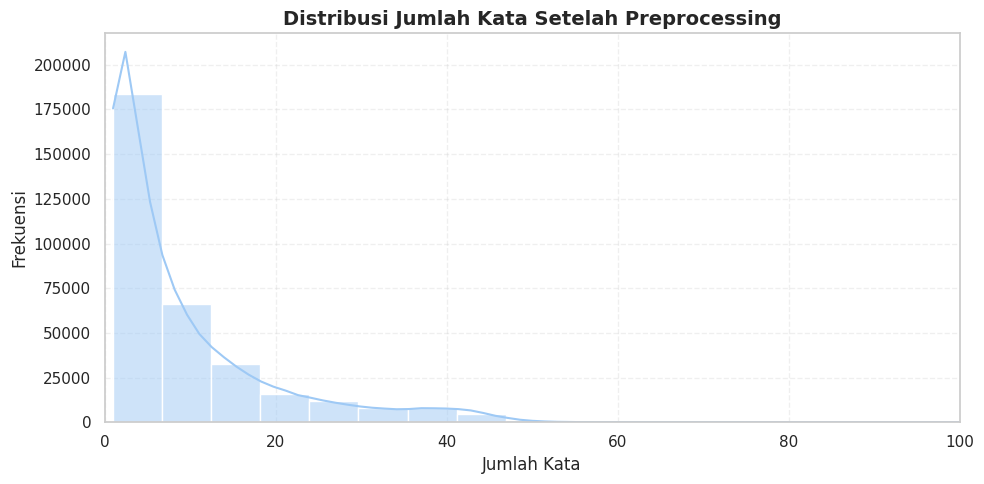

In [52]:
# ============================================================
# VISUALISASI PANJANG TEKS
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_bow,
    x="word_count",
    bins=50,
    kde=True,
    color="#9EC9F5"
)

plt.title("Distribusi Jumlah Kata Setelah Preprocessing", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.xlim(0, 100)
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# BAG OF WORDS

In [53]:
# ============================================================
# FUNGSI MEMBUAT BAG OF WORDS N-GRAMS
# ============================================================

MIN_DF = 10
MAX_DF = 0.95

def create_bow_ngram(texts, ngram_range, term_column_name):
    vectorizer = CountVectorizer(
        min_df=MIN_DF,
        max_df=MAX_DF,
        ngram_range=ngram_range
    )

    matrix = vectorizer.fit_transform(texts)
    features = vectorizer.get_feature_names_out()
    counts = np.asarray(matrix.sum(axis=0)).flatten()

    result_df = pd.DataFrame({
        term_column_name: features,
        "frequency": counts
    })

    result_df = result_df.sort_values(
        by="frequency",
        ascending=False
    ).reset_index(drop=True)

    return vectorizer, matrix, result_df

In [54]:
# ============================================================
# BAG OF WORDS - UNIGRAM
# ============================================================

bow_unigram_vectorizer, bow_unigram_matrix, bow_unigram_df = create_bow_ngram(
    df_bow["bow_text"],
    ngram_range=(1, 1),
    term_column_name="word"
)

print("Ukuran matrix BoW Unigram:")
print(bow_unigram_matrix.shape)

bow_unigram_df.head(30)

Ukuran matrix BoW Unigram:
(332562, 7629)


,word,frequency
0,love,40609
1,great,40204
2,time,35645
3,get,34300
4,order,33220
5,good,30966
6,item,30718
7,cannot,29854
8,use,28758
9,service,25892


In [55]:
# ============================================================
# BAG OF WORDS - BIGRAM
# ============================================================

bow_bigram_vectorizer, bow_bigram_matrix, bow_bigram_df = create_bow_ngram(
    df_bow["bow_text"],
    ngram_range=(2, 2),
    term_column_name="bigram"
)

print("Ukuran matrix BoW Bigram:")
print(bow_bigram_matrix.shape)

bow_bigram_df.head(30)

Ukuran matrix BoW Bigram:
(332562, 38211)


,bigram,frequency
0,customer service,12590
1,easy use,7518
2,every time,3854
3,please fix,3544
4,cannot even,2917
5,gift card,2699
6,keep crashing,2685
7,next day,2653
8,cannot get,2519
9,new update,2489


In [56]:
# ============================================================
# BAG OF WORDS - TRIGRAM
# ============================================================

bow_trigram_vectorizer, bow_trigram_matrix, bow_trigram_df = create_bow_ngram(
    df_bow["bow_text"],
    ngram_range=(3, 3),
    term_column_name="trigram"
)

print("Ukuran matrix BoW Trigram:")
print(bow_trigram_matrix.shape)

bow_trigram_df.head(30)

Ukuran matrix BoW Trigram:
(332562, 8606)


,trigram,frequency
0,something went wrong,1469
1,since last update,847
2,next day delivery,830
3,great customer service,671
4,search bar bottom,604
5,went wrong end,601
6,every time try,552
7,get money back,524
8,great place shop,510
9,great easy use,508


In [57]:
# ============================================================
# CONTOH BOW MATRIX
# ============================================================

bow_features = bow_unigram_vectorizer.get_feature_names_out()

bow_matrix_sample = pd.DataFrame(
    bow_unigram_matrix[:10, :20].toarray(),
    columns=bow_features[:20]
)

print("Contoh BoW matrix 10 dokumen pertama dan 20 fitur pertama:")
bow_matrix_sample

Contoh BoW matrix 10 dokumen pertama dan 20 fitur pertama:


,aaa,aang,aap,ab,abandon,abandoned,abd,abhorrent,ability,abit,able,abomination,abortion,abroad,abruptly,absent,absolute,absolutely,absolutley,absolutly
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [58]:
# ============================================================
# FUNGSI VISUALISASI TOP TERMS
# ============================================================

def plot_top_terms(data, term_col, value_col, title, xlabel, palette="viridis", top_n=30):
    top_data = data.head(top_n)

    plt.figure(figsize=(11, 8))

    ax = sns.barplot(
        data=top_data,
        x=value_col,
        y=term_col,
        hue=term_col,
        palette=palette,
        legend=False
    )

    plt.title(title, fontsize=15, fontweight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(term_col.capitalize())

    for container in ax.containers:
        if pd.api.types.is_float_dtype(top_data[value_col]):
            ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)
        else:
            ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

    plt.grid(axis="x", linestyle="--", alpha=0.3)
    sns.despine()

    plt.tight_layout()
    plt.show()

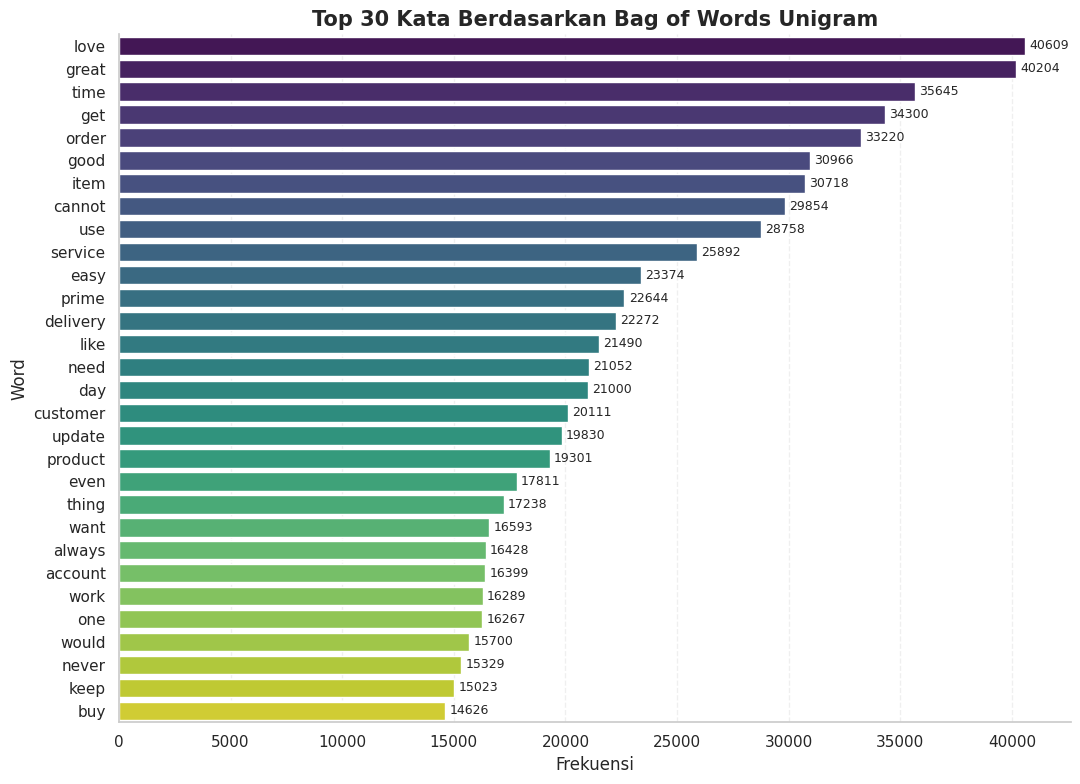

In [59]:
# ============================================================
# VISUALISASI TOP 30 BOW UNIGRAM
# ============================================================

plot_top_terms(
    data=bow_unigram_df,
    term_col="word",
    value_col="frequency",
    title="Top 30 Kata Berdasarkan Bag of Words Unigram",
    xlabel="Frekuensi",
    palette="viridis",
    top_n=30
)

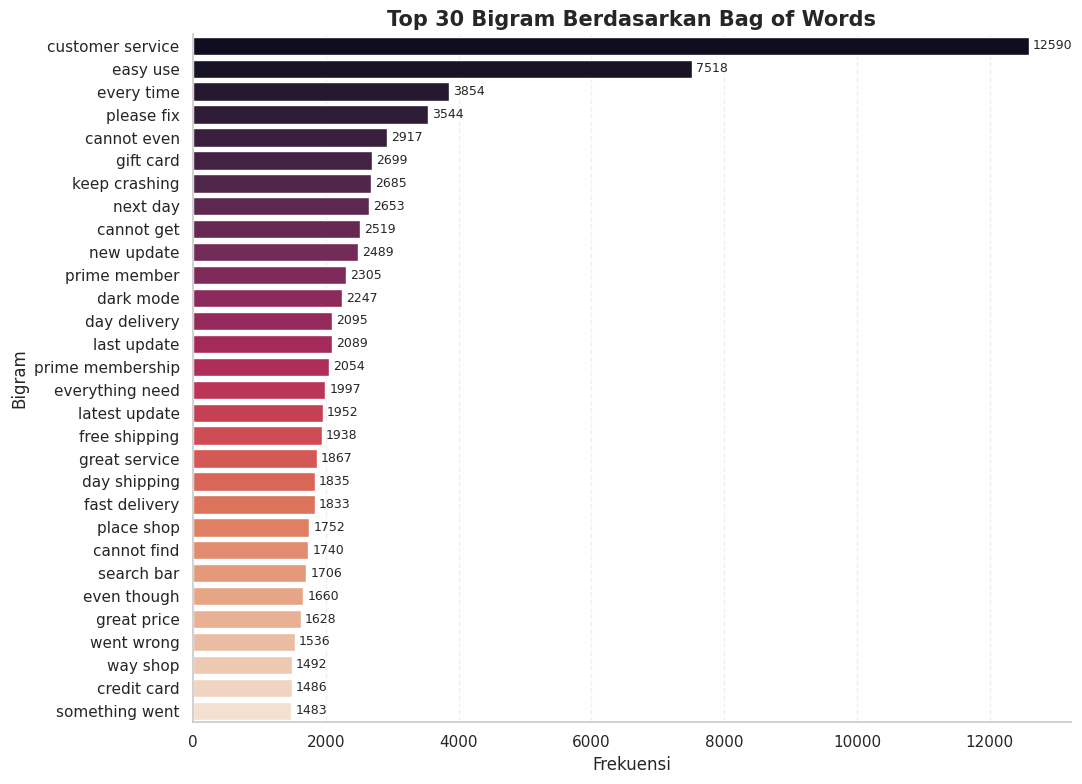

In [60]:
# ============================================================
# VISUALISASI TOP 30 BOW BIGRAM
# ============================================================

plot_top_terms(
    data=bow_bigram_df,
    term_col="bigram",
    value_col="frequency",
    title="Top 30 Bigram Berdasarkan Bag of Words",
    xlabel="Frekuensi",
    palette="rocket",
    top_n=30
)

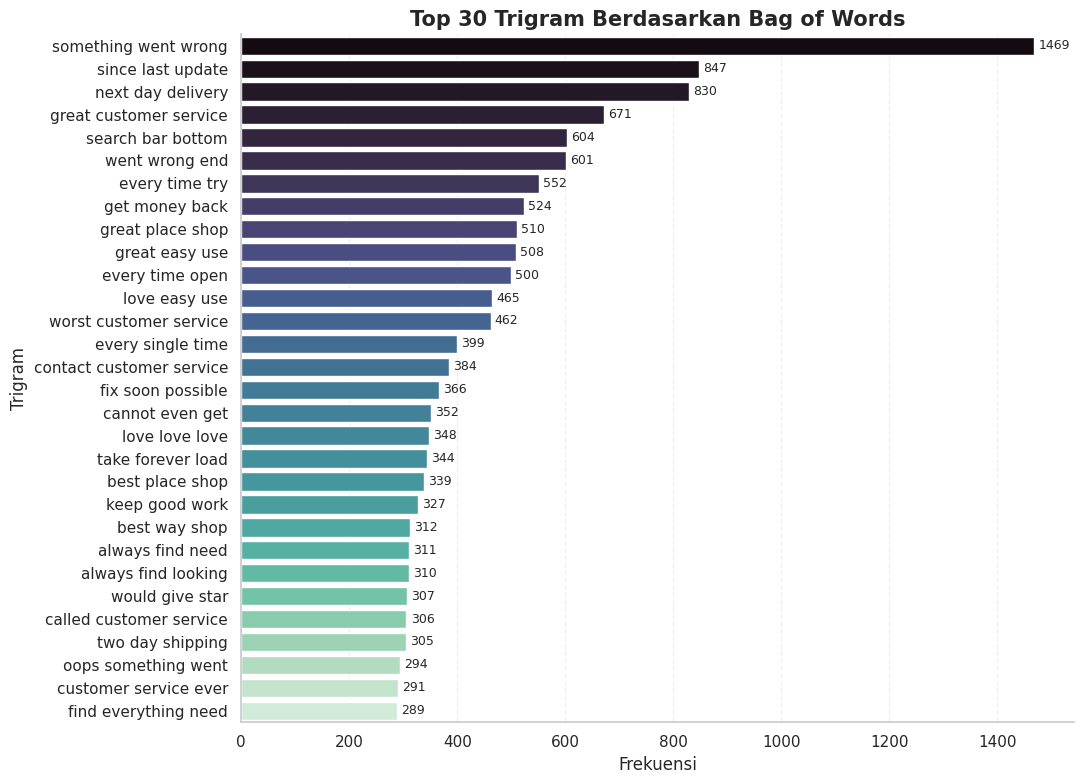

In [61]:
# ============================================================
# VISUALISASI TOP 30 BOW TRIGRAM
# ============================================================

plot_top_terms(
    data=bow_trigram_df,
    term_col="trigram",
    value_col="frequency",
    title="Top 30 Trigram Berdasarkan Bag of Words",
    xlabel="Frekuensi",
    palette="mako",
    top_n=30
)

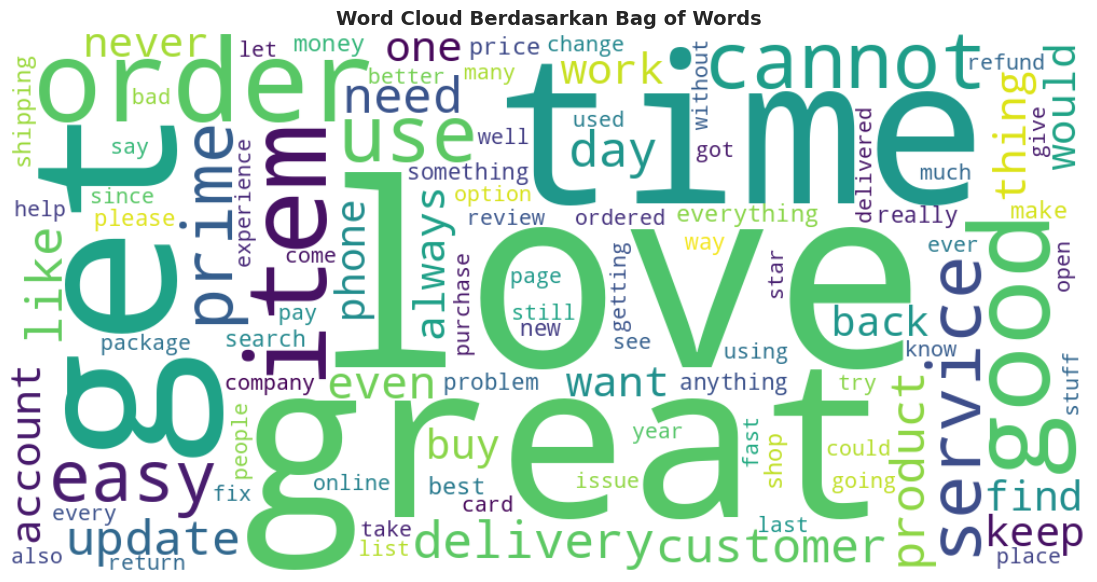

In [62]:
# ============================================================
# WORD CLOUD BERDASARKAN BOW UNIGRAM
# ============================================================

bow_word_freq = dict(zip(bow_unigram_df["word"], bow_unigram_df["frequency"]))

wordcloud_bow = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate_from_frequencies(bow_word_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_bow, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Berdasarkan Bag of Words", fontsize=14, fontweight="bold")
plt.show()

# TF-IDF

In [63]:
# ============================================================
# FUNGSI MEMBUAT TF-IDF N-GRAMS
# ============================================================

def create_tfidf_ngram(texts, ngram_range, term_column_name):
    vectorizer = TfidfVectorizer(
        min_df=MIN_DF,
        max_df=MAX_DF,
        ngram_range=ngram_range
    )

    matrix = vectorizer.fit_transform(texts)
    features = vectorizer.get_feature_names_out()
    scores = np.asarray(matrix.mean(axis=0)).flatten()

    result_df = pd.DataFrame({
        term_column_name: features,
        "tfidf_score": scores
    })

    result_df = result_df.sort_values(
        by="tfidf_score",
        ascending=False
    ).reset_index(drop=True)

    return vectorizer, matrix, result_df

In [64]:
# ============================================================
# TF-IDF - UNIGRAM
# ============================================================

tfidf_unigram_vectorizer, tfidf_unigram_matrix, tfidf_unigram_df = create_tfidf_ngram(
    df_bow["bow_text"],
    ngram_range=(1, 1),
    term_column_name="word"
)

print("Ukuran matrix TF-IDF Unigram:")
print(tfidf_unigram_matrix.shape)

tfidf_unigram_df.head(30)

Ukuran matrix TF-IDF Unigram:
(332562, 7629)


,word,tfidf_score
0,great,0.057330
1,love,0.049847
2,good,0.034749
3,easy,0.026097
4,use,0.021898
5,best,0.019253
6,time,0.018499
7,service,0.017461
8,get,0.016729
9,order,0.016319


In [65]:
# ============================================================
# TF-IDF - BIGRAM
# ============================================================

tfidf_bigram_vectorizer, tfidf_bigram_matrix, tfidf_bigram_df = create_tfidf_ngram(
    df_bow["bow_text"],
    ngram_range=(2, 2),
    term_column_name="bigram"
)

print("Ukuran matrix TF-IDF Bigram:")
print(tfidf_bigram_matrix.shape)

tfidf_bigram_df.head(30)

Ukuran matrix TF-IDF Bigram:
(332562, 38211)


,bigram,tfidf_score
0,easy use,0.011128
1,customer service,0.006993
2,keep crashing,0.004003
3,great service,0.003348
4,everything need,0.002637
5,every time,0.002546
6,please fix,0.002479
7,place shop,0.002434
8,dark mode,0.002340
9,good service,0.002240


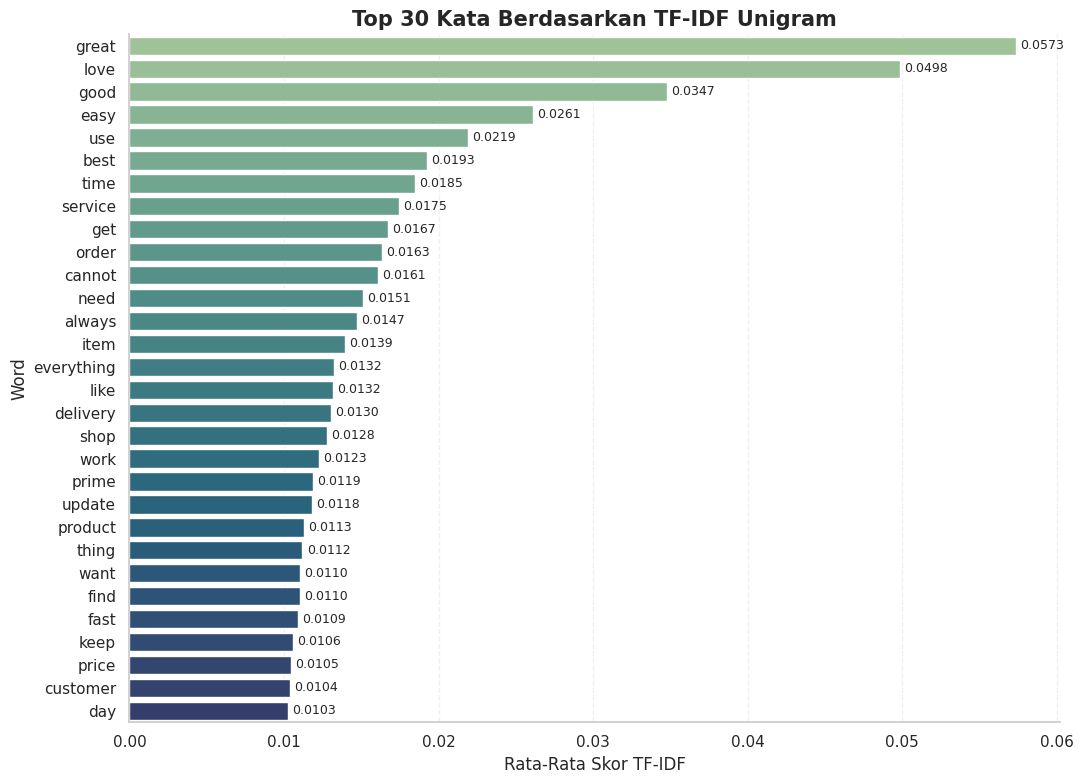

In [66]:
# ============================================================
# VISUALISASI TOP 30 TF-IDF UNIGRAM
# ============================================================

plot_top_terms(
    data=tfidf_unigram_df,
    term_col="word",
    value_col="tfidf_score",
    title="Top 30 Kata Berdasarkan TF-IDF Unigram",
    xlabel="Rata-Rata Skor TF-IDF",
    palette="crest",
    top_n=30
)

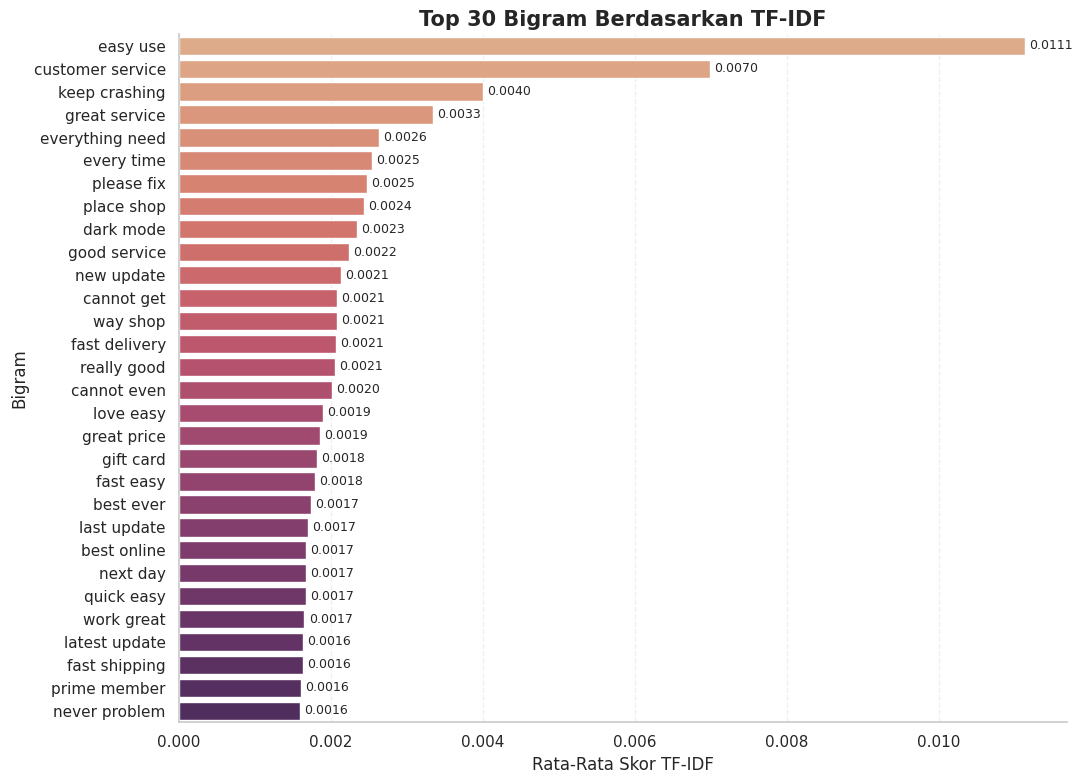

In [67]:
# ============================================================
# VISUALISASI TOP 30 TF-IDF BIGRAM
# ============================================================

plot_top_terms(
    data=tfidf_bigram_df,
    term_col="bigram",
    value_col="tfidf_score",
    title="Top 30 Bigram Berdasarkan TF-IDF",
    xlabel="Rata-Rata Skor TF-IDF",
    palette="flare",
    top_n=30
)

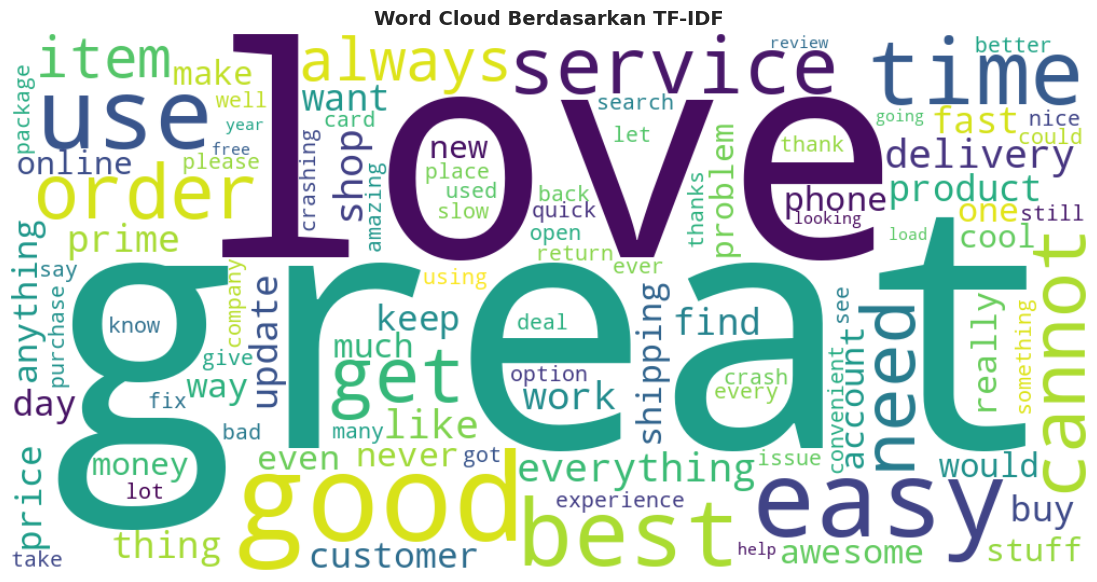

In [68]:
# ============================================================
# WORD CLOUD BERDASARKAN TF-IDF UNIGRAM
# ============================================================

tfidf_word_freq = dict(zip(tfidf_unigram_df["word"], tfidf_unigram_df["tfidf_score"]))

wordcloud_tfidf = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate_from_frequencies(tfidf_word_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_tfidf, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Berdasarkan TF-IDF", fontsize=14, fontweight="bold")
plt.show()

In [69]:
# ============================================================
# TABEL PERBANDINGAN BOW DAN TF-IDF
# ============================================================

comparison_table = pd.DataFrame({
    "Top BoW Unigram": bow_unigram_df.head(20)["word"].values,
    "BoW Frequency": bow_unigram_df.head(20)["frequency"].values,
    "Top TF-IDF Unigram": tfidf_unigram_df.head(20)["word"].values,
    "TF-IDF Score": tfidf_unigram_df.head(20)["tfidf_score"].round(4).values
})

comparison_table

,Top BoW Unigram,BoW Frequency,Top TF-IDF Unigram,TF-IDF Score
0,love,40609,great,0.0573
1,great,40204,love,0.0498
2,time,35645,good,0.0347
3,get,34300,easy,0.0261
4,order,33220,use,0.0219
5,good,30966,best,0.0193
6,item,30718,time,0.0185
7,cannot,29854,service,0.0175
8,use,28758,get,0.0167
9,service,25892,order,0.0163


In [70]:
# ============================================================
# TOP WORDS BERDASARKAN SENTIMEN
# ============================================================

if "sentiment_textblob" in df_bow.columns:
    sentiment_groups = ["Positive", "Neutral", "Negative"]
    sentiment_top_words = []

    for sentiment in sentiment_groups:
        texts = df_bow[df_bow["sentiment_textblob"] == sentiment]["bow_text"]

        if len(texts) > 0:
            vectorizer = CountVectorizer(
                min_df=5,
                max_df=0.95,
                ngram_range=(1, 1)
            )

            matrix = vectorizer.fit_transform(texts)
            features = vectorizer.get_feature_names_out()
            counts = np.asarray(matrix.sum(axis=0)).flatten()

            temp_df = pd.DataFrame({
                "sentiment": sentiment,
                "word": features,
                "frequency": counts
            })

            temp_df = temp_df.sort_values(
                by="frequency",
                ascending=False
            ).head(20)

            sentiment_top_words.append(temp_df)

    sentiment_top_words_df = pd.concat(sentiment_top_words, ignore_index=True)

    sentiment_top_words_df
else:
    sentiment_top_words_df = pd.DataFrame(columns=["sentiment", "word", "frequency"])
    print("Kolom sentiment_textblob tidak ditemukan.")

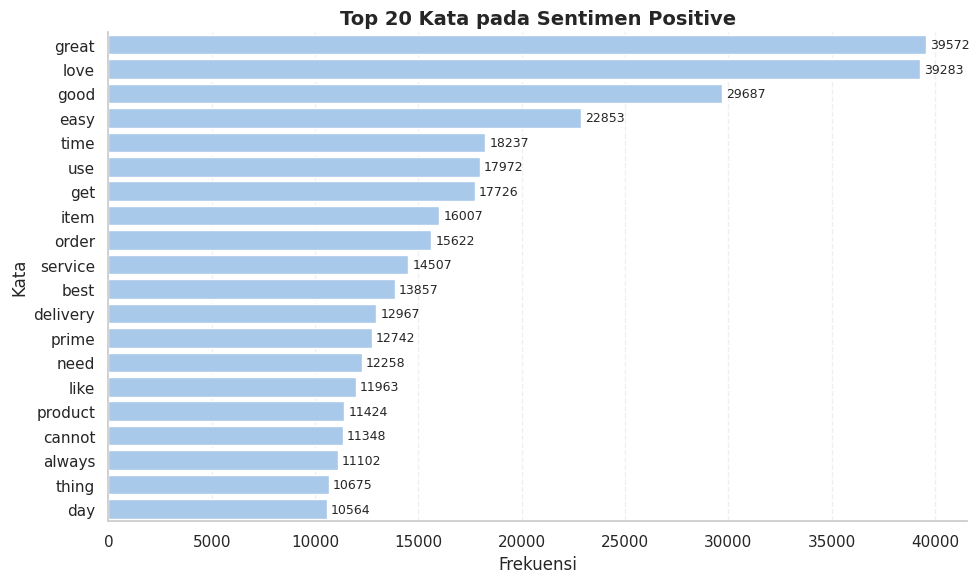

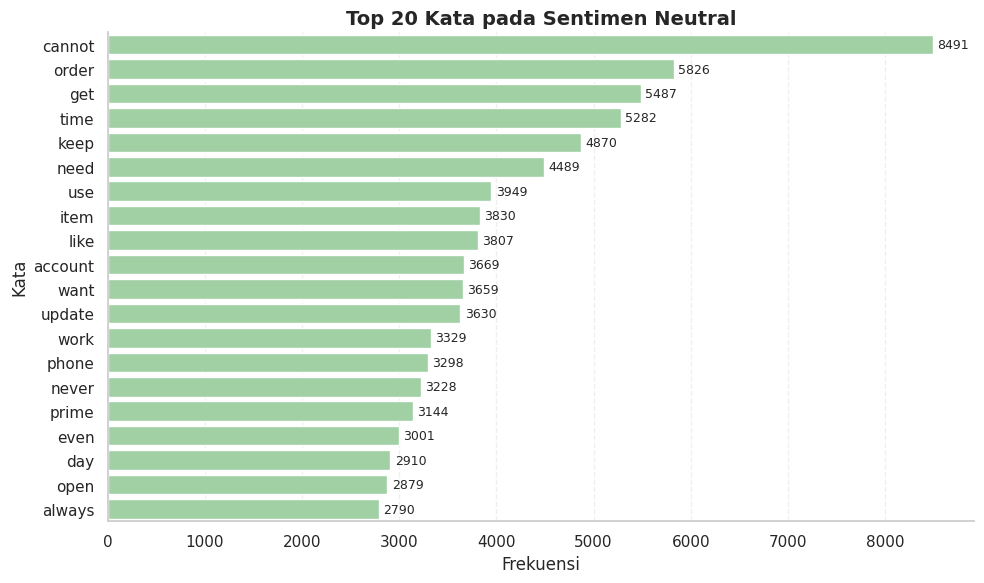

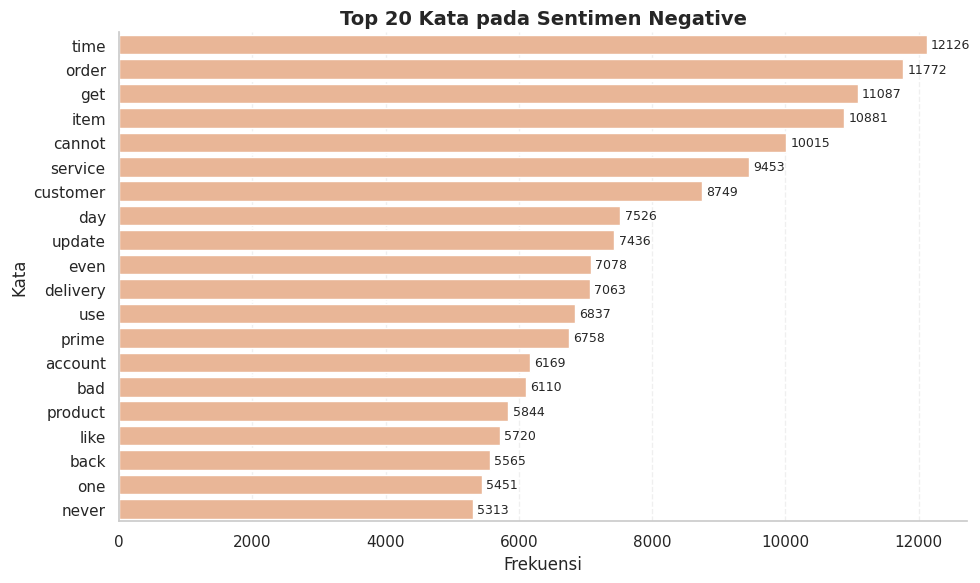

In [71]:
# ============================================================
# VISUALISASI TOP WORDS PER SENTIMEN
# ============================================================

sentiment_palette = {
    "Positive": "#9EC9F5",
    "Neutral": "#98D89E",
    "Negative": "#F6B38A"
}

if len(sentiment_top_words_df) > 0:
    for sentiment in ["Positive", "Neutral", "Negative"]:
        temp = sentiment_top_words_df[sentiment_top_words_df["sentiment"] == sentiment]

        plt.figure(figsize=(10, 6))

        ax = sns.barplot(
            data=temp,
            x="frequency",
            y="word",
            color=sentiment_palette[sentiment]
        )

        plt.title(f"Top 20 Kata pada Sentimen {sentiment}", fontsize=14, fontweight="bold")
        plt.xlabel("Frekuensi")
        plt.ylabel("Kata")

        for container in ax.containers:
            ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

        plt.grid(axis="x", linestyle="--", alpha=0.3)
        sns.despine()

        plt.tight_layout()
        plt.show()

In [72]:
# ============================================================
# RINGKASAN HASIL BOW DAN TF-IDF
# ============================================================

summary = {
    "Jumlah data awal": df.shape[0],
    "Jumlah data digunakan": df_bow.shape[0],
    "Jumlah fitur BoW unigram": bow_unigram_matrix.shape[1],
    "Jumlah fitur BoW bigram": bow_bigram_matrix.shape[1],
    "Jumlah fitur BoW trigram": bow_trigram_matrix.shape[1],
    "Jumlah fitur TF-IDF unigram": tfidf_unigram_matrix.shape[1],
    "Jumlah fitur TF-IDF bigram": tfidf_bigram_matrix.shape[1]
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Keterangan", "Nilai"]
)

summary_df

,Keterangan,Nilai
0,Jumlah data awal,332562
1,Jumlah data digunakan,332562
2,Jumlah fitur BoW unigram,7629
3,Jumlah fitur BoW bigram,38211
4,Jumlah fitur BoW trigram,8606
5,Jumlah fitur TF-IDF unigram,7629
6,Jumlah fitur TF-IDF bigram,38211


In [73]:
# ============================================================
# SIMPAN OUTPUT CSV
# ============================================================

bow_unigram_df.to_csv(BOW_UNIGRAM_OUTPUT, index=False, encoding="utf-8")
bow_bigram_df.to_csv(BOW_BIGRAM_OUTPUT, index=False, encoding="utf-8")
bow_trigram_df.to_csv(BOW_TRIGRAM_OUTPUT, index=False, encoding="utf-8")

tfidf_unigram_df.to_csv(TFIDF_UNIGRAM_OUTPUT, index=False, encoding="utf-8")
tfidf_bigram_df.to_csv(TFIDF_BIGRAM_OUTPUT, index=False, encoding="utf-8")

bow_matrix_sample.to_csv(BOW_MATRIX_SAMPLE_OUTPUT, index=False, encoding="utf-8")

print("Semua output CSV berhasil disimpan.")

Semua output CSV berhasil disimpan.


In [74]:
# ============================================================
# SIMPAN OUTPUT EXCEL
# ============================================================

with pd.ExcelWriter(EXCEL_OUTPUT, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="summary", index=False)
    bow_unigram_df.head(1000).to_excel(writer, sheet_name="bow_unigram", index=False)
    bow_bigram_df.head(1000).to_excel(writer, sheet_name="bow_bigram", index=False)
    bow_trigram_df.head(1000).to_excel(writer, sheet_name="bow_trigram", index=False)
    tfidf_unigram_df.head(1000).to_excel(writer, sheet_name="tfidf_unigram", index=False)
    tfidf_bigram_df.head(1000).to_excel(writer, sheet_name="tfidf_bigram", index=False)
    comparison_table.to_excel(writer, sheet_name="comparison", index=False)
    sentiment_top_words_df.to_excel(writer, sheet_name="sentiment_words", index=False)
    bow_matrix_sample.to_excel(writer, sheet_name="bow_matrix_sample", index=False)

print("File Excel berhasil disimpan:")
print(EXCEL_OUTPUT)

File Excel berhasil disimpan:
data/amazon_bow_tfidf_summary.xlsx


In [75]:
# ============================================================
# DOWNLOAD FILE OUTPUT UNTUK UPLOAD KE GITHUB
# ============================================================

from google.colab import files

files.download(BOW_UNIGRAM_OUTPUT)
files.download(BOW_BIGRAM_OUTPUT)
files.download(BOW_TRIGRAM_OUTPUT)
files.download(TFIDF_UNIGRAM_OUTPUT)
files.download(TFIDF_BIGRAM_OUTPUT)
files.download(BOW_MATRIX_SAMPLE_OUTPUT)
files.download(EXCEL_OUTPUT)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>